In [1]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd

import seaborn as sns
import torch
import config
from models import SingleTransformer
from utils.helpers import get_max, get_all_modalities_available_samples
from train import train_mlm, train_cls
from evaluate import evaluate_cls_cv
from data import load_data, create_dataset, preprocess_data
from interpretation import visualization as viz

np.random.seed(config.SEED)
torch.manual_seed(config.SEED)
torch.cuda.manual_seed(config.SEED)

# Load Data

Loading RNA data...
Filtering RNA data...
Feature Selection by DEGs...
Filtering Genes...
RNA data loaded. 
RNA D3 Labelled: (2008, 944) (2008, 16) ['Eppk1', 'Zbtb7c', 'Krt8', 'Fam212a', 'Dhrs9'] ... 
RNA D3 Un-Labelled: (100254, 944) (100254, 8) ['Eppk1', 'Zbtb7c', 'Krt8', 'Fam212a', 'Dhrs9'] ...
ATAC data loaded. 
ATAC D3 Labelled: (265, 883) (265, 12) ['Tcfap2a_1', 'Tcfap2b_2', 'Tcfap2c_3', 'Tcfap2e_4', 'Tcfap2d_5'] ... 
ATAC D3 Un-Labelled: (54824, 883) (54824, 1) ['Tcfap2a_1', 'Tcfap2b_2', 'Tcfap2c_3', 'Tcfap2e_4', 'Tcfap2d_5'] ...
Flux data loaded. 
Flux D3 Labelled: (2008, 168) ['Glucose→G6P', 'G6P→G3P', 'G3P→3PD', '3PD→Pyruvate', 'Pyruvate→Acetyl-Coa'] ... 
Flux D3 Un-Labelled: (100254, 168) ['Glucose→G6P', 'G6P→G3P', 'G3P→3PD', '3PD→Pyruvate', 'Pyruvate→Acetyl-Coa'] ...


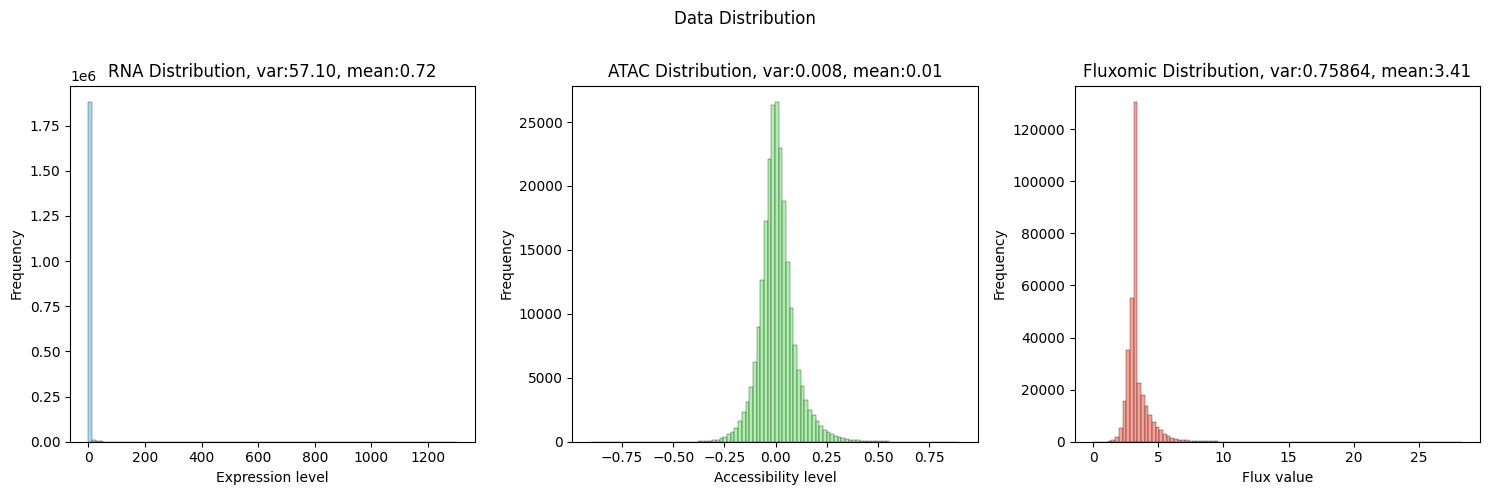

In [6]:
try:
    adata_RNA_labelled, adata_RNA_unlabelled, df_degs, adata_RNA_labelled_all = load_data.load_processed_rna(verbose=True, 
                                                                                                             return_raw=True, 
                                                                                                             return_all_features=True)

    # rename dataframe column 'gene' to 'feature' iin df_degs
    df_degs = df_degs.rename(columns={"gene": "feature", "mean_exp_de": "mean_de", "mean_exp_re": "mean_re", "std_exp_de": "std_de", "std_exp_re": "std_re"})
    df_degs["mean_diff"] = df_degs["mean_de"] - df_degs["mean_re"]

    print("RNA data loaded.",
            "\nRNA D3 Labelled:", adata_RNA_labelled.shape, adata_RNA_labelled.obs.shape,  list(adata_RNA_labelled.var_names)[:5],"...",
            "\nRNA D3 Un-Labelled:", adata_RNA_unlabelled.shape, adata_RNA_unlabelled.obs.shape, list(adata_RNA_unlabelled.var_names)[:5],"...")

    adata_ATAC_labelled, adata_ATAC_unlabelled = load_data.load_atac(data_path="datasets/all_atac_d3_motif.h5ad",
                                                                     clone_info=True, clone_path="datasets/clones.csv")


    print("ATAC data loaded.",
            "\nATAC D3 Labelled:", adata_ATAC_labelled.shape, adata_ATAC_labelled.obs.shape,  list(adata_ATAC_labelled.var_names)[:5],"...",
            "\nATAC D3 Un-Labelled:", adata_ATAC_unlabelled.shape, adata_ATAC_unlabelled.obs.shape, list(adata_ATAC_unlabelled.var_names)[:5],"...")

    fluxes = load_data.load_flux("datasets/flux_labelled.csv", prefix="flux_un",
                                                                     clone_info=True, clone_path="datasets/clones.csv", scale=True)
    adata_Flux_labelled, adata_Flux_unlabelled, bi_labelled, bi_unlabelled, flux_labels, pcts = fluxes

    df_atac_degs = preprocess_data.get_atac_degs(adata_ATAC_labelled)
    df_flux_degs = preprocess_data.get_flux_degs(adata_Flux_labelled, flux_labels)
    flux_metadata = pd.read_csv("datasets/metabolic_model_metadata.csv")[["Super.Module.class", "rxnName", "X"]]
    flux_metadata.columns = ["pathway", "feature", "module"]
    flux_metadata['feature'] = flux_metadata['feature'].str.replace(" -> ", "→")
    df_flux_degs = df_flux_degs.merge(flux_metadata, on="feature", how="left")

    print("Flux data loaded.",
            "\nFlux D3 Labelled:", adata_Flux_labelled.shape, list(adata_Flux_labelled.columns)[:5],"...",
            "\nFlux D3 Un-Labelled:", adata_Flux_unlabelled.shape, list(adata_Flux_unlabelled.columns)[:5],"...")

    viz.plot_data_distribution(adata_RNA_labelled, adata_ATAC_labelled, adata_Flux_labelled)

except FileNotFoundError as e:
    print("Dataset files were not found.")
    print("Please download the dataset from: https://zenodo.org/records/17864926")
    print("Then place the downloaded files in the 'datasets/' folder, as described in README.md.")
    raise e

# Create Multimodal Dataset

In [7]:
X, y_label, b, df_indices, pcts = create_dataset.get_pair_modalities(adata_RNA_labelled, 
                                                               adata_ATAC_labelled, 
                                                               adata_Flux_labelled, 
                                                               include_unused_atacs=True,
                                                               seed=42)

feature_names = list(X[0].columns) + ['batch_rna'] + list(X[1].columns) + ['batch_atac'] + list(X[2].columns) + ['batch_flux']

y_number = torch.tensor([{'reprogramming':1, 'dead-end':0}[i] for i in list(y_label)], 
                        dtype=torch.float32)

# Create dataset with all samples
multimodal_dataset = create_dataset.MultiModalDataset(X, b, y_number)

# Create dataset with only samples that have all modalities available
multimodal_dataset_all = get_all_modalities_available_samples(multimodal_dataset)

print("Full dataset:")
print("X[0] RNA shape:", X[0].shape, "X[1] ATAC shape:", X[1].shape, "X[2] Flux shape:", X[2].shape)
print("y_label shape:", y_label.shape, "y_number shape:", y_number.shape, "b shape:", b.shape)
print("df_indices shape:", df_indices.shape, "pcts shape:", pcts.shape)
print("Feature names:", len(feature_names), feature_names[:5], "...")

print("\nDataset with all modalities available:")
print("RNA shape:", multimodal_dataset_all.rna_data.shape)
print("ATAC shape:", multimodal_dataset_all.atac_data.shape) 
print("Flux shape:", multimodal_dataset_all.flux_data.shape)
print("Labels shape:", multimodal_dataset_all.labels.shape)
print("Batch shape:", multimodal_dataset_all.batch_no.shape)

Full dataset:
X[0] RNA shape: (2110, 944) X[1] ATAC shape: (2110, 883) X[2] Flux shape: (2110, 168)
y_label shape: (2110,) y_number shape: torch.Size([2110]) b shape: (2110,)
df_indices shape: (2110, 2) pcts shape: (2110,)
Feature names: 1998 ['Eppk1', 'Zbtb7c', 'Krt8', 'Fam212a', 'Dhrs9'] ...

Dataset with all modalities available:
RNA shape: torch.Size([163, 944])
ATAC shape: torch.Size([163, 883])
Flux shape: torch.Size([163, 168])
Labels shape: torch.Size([163])
Batch shape: torch.Size([163])


# Config Model

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

share_config = {
    "d_model": 128,
    "d_ff": 16,
    "n_heads": 8,
    "n_encoder_layers": 2,
    "n_batches": 3,
    "dropout_rate": 0.2,
}
model_config_rna = {
    "vocab_size": int(get_max([adata_RNA_labelled, adata_RNA_unlabelled])) + 2,
    "seq_len": X[0].shape[1],
}
model_config_atac = {
    "vocab_size": 1,
    "seq_len": X[1].shape[1],
}
model_config_flux = {
    "vocab_size": 1,
    "seq_len": X[2].shape[1],
}
model_config_multi = {
    "d_model": 128,
    "n_heads_cls": 8,
    "d_ff_cls": 16,
}

model_config = {"Share": share_config, "RNA": model_config_rna, "ATAC": model_config_atac, "Flux": model_config_flux, "Multi": model_config_multi}

# MLM Pretraining
**Skip this cell if you have already pretrained the model or you want to use pretrained weights stored in ckp/MLM**

Run this before CLS training so unimodal encoders are initialized with MLM checkpoints.

In [ ]:
mlm_train_loader_rna, mlm_val_loader_rna = create_dataset.get_mlm_loaders(
    train_data=adata_RNA_unlabelled,
    val_data=adata_RNA_labelled,
    batch_size=32,
    batch_key="batch_no",
    data_dtype=torch.int32,
)

mlm_train_loader_atac, mlm_val_loader_atac = create_dataset.get_mlm_loaders(
    train_data=adata_ATAC_unlabelled,
    val_data=adata_ATAC_labelled,
    batch_size=32,
    batch_key="batch_no",
    data_dtype=torch.float32,
)

mlm_train_loader_flux, mlm_val_loader_flux = create_dataset.get_mlm_loaders(
    train_data=(adata_Flux_unlabelled, bi_unlabelled),
    val_data=(adata_Flux_labelled, bi_labelled),
    batch_size=32,
    batch_key=None,
    data_dtype=torch.float32,
)

rna_model = SingleTransformer("RNA", **model_config["RNA"], **model_config["Share"]).to(device)
atac_model = SingleTransformer("ATAC", **model_config["ATAC"], **model_config["Share"]).to(device)
flux_model = SingleTransformer("Flux", **model_config["Flux"], **model_config["Share"]).to(device)

_, rna_val_loss = train_mlm(
    rna_model,
    mlm_train_loader_rna,
    mlm_val_loader_rna,
    device,
    mse_based=False,
    epochs=10,
    lr=1e-3,
    weight_decay=0,
    tune_lr=True,
    save_folder="ckp/MLM/",
    model_type="RNA",
    use_multiple_gpu=False,
)

_, atac_val_loss = train_mlm(
    atac_model,
    mlm_train_loader_atac,
    mlm_val_loader_atac,
    device,
    mse_based=True,
    epochs=10,
    lr=1e-3,
    weight_decay=0,
    tune_lr=True,
    save_folder="ckp/MLM/",
    model_type="ATAC",
    use_multiple_gpu=False,
)

_, flux_val_loss = train_mlm(
    flux_model,
    mlm_train_loader_flux,
    mlm_val_loader_flux,
    device,
    mse_based=True,
    epochs=10,
    lr=5e-4,
    weight_decay=1e-2,
    tune_lr=True,
    save_folder="ckp/MLM/",
    model_type="Flux",
    use_multiple_gpu=False,
)

config.MLM_RNA_CKP = f"ckp/MLM/MLM_RNA_ValLoss{min(rna_val_loss):.4f}.pth"
config.MLM_ATAC_CKP = f"ckp/MLM/MLM_ATAC_ValLoss{min(atac_val_loss):.4f}.pth"
config.MLM_FLUX_CKP = f"ckp/MLM/MLM_Flux_ValLoss{min(flux_val_loss):.4f}.pth"

print("Using MLM checkpoints for multimodal CLS run:")
print("RNA:", config.MLM_RNA_CKP)
print("ATAC:", config.MLM_ATAC_CKP)
print("Flux:", config.MLM_FLUX_CKP)

# Train Model

In [ ]:
fold_results = train_cls("Multi", model_config, 
                        multimodal_dataset, k_folds=5, batch_size=16, 
                        epochs=15, lr=5e-4, weight_decay=1e-3,
                        use_mlm=True, mlm_path=None, save_path="ckp/CLS", 
                        device=device, loss_fn="w_bce", seed=42)

print(f"Cross-Validation Results:\n"
    f"Train AUC: {np.mean([fr['train_auc'] for fr in fold_results]):.4f} ± {np.std([fr['train_auc'] for fr in fold_results]):.4f}, "
    f"Valid AUC: {np.mean([fr['best_val_auc'] for fr in fold_results]):.4f} ± {np.std([fr['best_val_auc'] for fr in fold_results]):.4f}, "
    f"Valid Precision: {np.mean([fr['best_precision'] for fr in fold_results]):.4f} ± {np.std([fr['best_precision'] for fr in fold_results]):.4f}, "
    f"Valid Recall: {np.mean([fr['best_recall'] for fr in fold_results]):.4f} ± {np.std([fr['best_recall'] for fr in fold_results]):.4f},\n"
    f"Valid F1: {np.mean([fr['best_f1'] for fr in fold_results]):.4f} ± {np.std([fr['best_f1'] for fr in fold_results]):.4f}, "
    f"Valid Accuracy: {np.mean([fr['best_accuracy'] for fr in fold_results]):.4f} ± {np.std([fr['best_accuracy'] for fr in fold_results]):.4f}, "
    f"Valid Specificity: {np.mean([fr['best_specificity'] for fr in fold_results]):.4f} ± {np.std([fr['best_specificity'] for fr in fold_results]):.4f}")

In [ ]:
fold_results_nomlm = train_cls("Multi", model_config, 
                            multimodal_dataset, k_folds=5, batch_size=16, 
                            epochs=15, lr=5e-4, weight_decay=1e-3,
                            use_mlm=False, mlm_path=None, save_path="ckp/CLS", 
                            device=device, loss_fn="w_bce", seed=42)

print(f"Cross-Validation Results:\n"
    f"Train AUC: {np.mean([fr['train_auc'] for fr in fold_results_nomlm]):.4f} ± {np.std([fr['train_auc'] for fr in fold_results_nomlm]):.4f}, "
    f"Valid AUC: {np.mean([fr['best_val_auc'] for fr in fold_results_nomlm]):.4f} ± {np.std([fr['best_val_auc'] for fr in fold_results_nomlm]):.4f}, "
    f"Valid Precision: {np.mean([fr['best_precision'] for fr in fold_results_nomlm]):.4f} ± {np.std([fr['best_precision'] for fr in fold_results_nomlm]):.4f}, "
    f"Valid Recall: {np.mean([fr['best_recall'] for fr in fold_results_nomlm]):.4f} ± {np.std([fr['best_recall'] for fr in fold_results_nomlm]):.4f}, "
    f"Valid F1: {np.mean([fr['best_f1'] for fr in fold_results_nomlm]):.4f} ± {np.std([fr['best_f1'] for fr in fold_results_nomlm]):.4f}, "
    f"Valid Accuracy: {np.mean([fr['best_accuracy'] for fr in fold_results_nomlm]):.4f} ± {np.std([fr['best_accuracy'] for fr in fold_results_nomlm]):.4f}")


# Evaluate Model

In [ ]:
# compute mean and std of train_auc and best_val_auc keys in fold_results and fold_results_nomlm
train_auc_mlm = np.mean([fr['train_auc'] for fr in fold_results])
train_auc_nomlm = np.mean([fr['train_auc'] for fr in fold_results_nomlm])
train_auc_mlm_std = np.std([fr['train_auc'] for fr in fold_results])
train_auc_nomlm_std = np.std([fr['train_auc'] for fr in fold_results_nomlm])
best_val_auc_mlm = np.mean([fr['best_val_auc'] for fr in fold_results])
best_val_auc_nomlm = np.mean([fr['best_val_auc'] for fr in fold_results_nomlm])
best_val_auc_mlm_std = np.std([fr['best_val_auc'] for fr in fold_results])
best_val_auc_nomlm_std = np.std([fr['best_val_auc'] for fr in fold_results_nomlm])

print(f"Train AUC: MLM: {train_auc_mlm:.4f} ± {train_auc_mlm_std:.4f}, No-MLM: {train_auc_nomlm:.4f} ± {train_auc_nomlm_std:.4f}")
print(f"Best Val AUC: MLM: {best_val_auc_mlm:.4f} ± {best_val_auc_mlm_std:.4f}, No-MLM: {best_val_auc_nomlm:.4f} ± {best_val_auc_nomlm_std:.4f}")

In [ ]:
# print each fold best val auc separate based on mlm and no mlm 5 folds for each)
for i in range(5):
    print(f"Fold {i+1}: MLM: {fold_results[i]['best_val_auc']:.4f}, No-MLM: {fold_results_nomlm[i]['best_val_auc']:.4f}")
print(f"val auc mlm: {np.mean([fr['best_val_auc'] for fr in fold_results]):.4f} ± {np.std([fr['best_val_auc'] for fr in fold_results]):.4f}")
print(f"val auc no mlm: {np.mean([fr['best_val_auc'] for fr in fold_results_nomlm]):.4f} ± {np.std([fr['best_val_auc'] for fr in fold_results_nomlm]):.4f}")
# compute p-value for mlm and no-mlm values for val auc
from scipy.stats import ttest_rel
print("p-value for val auc: ", ttest_rel([fr['best_val_auc'] for fr in fold_results], [fr['best_val_auc'] for fr in fold_results_nomlm]))

In [ ]:
aucs_stored, aucs, val_preds, val_labels = evaluate_cls_cv("Multi", fold_results, model_config, multimodal_dataset, device)
print([f"({a:.4f} | {b:.4f})" for a,b in zip(aucs_stored, aucs)])
viz.plot_roc_auc_curve(val_preds, val_labels, m_type="multi", aggregate=False)